<a href="https://colab.research.google.com/github/7vika-lgtm/dataviz/blob/main/7_dataviz_global_development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Visualization: Telling the Story of Global Development
**Skill:** Data visualization with Matplotlib, Seaborn and Plotly.

**Story:** how have life expectancy and wealth changed across countries since 1952? Along the way you practise choosing the right chart, designing it well, and making it interactive.

**Data:** the Gapminder, Tips and Stocks datasets bundled with Plotly, so no downloads are needed. Everything runs in Colab as it is.

## 1. Setup and data

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px, plotly.graph_objects as go

sns.set_theme(style="whitegrid", context="notebook")
gap = px.data.gapminder()      # country-year data: life expectancy, population, GDP per person
tips = px.data.tips()
stocks = px.data.stocks()
print(gap.shape, "| years", gap.year.min(), "to", gap.year.max(), "|", gap.country.nunique(), "countries")
gap.head()

(1704, 8) | years 1952 to 2007 | 142 countries


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


## 2. Know your data first
Before any chart, look at summaries and check for gaps.

In [2]:
print("Missing values:", int(gap.isna().sum().sum()))
gap[gap.year == 2007][["lifeExp", "gdpPercap", "pop"]].describe().round(1)

Missing values: 0


,lifeExp,gdpPercap,pop
count,142.0,142.0,1.420000e+02
mean,67.0,11680.1,4.402122e+07
std,12.1,12859.9,1.476214e+08
min,39.6,277.6,1.995790e+05
25%,57.2,1624.8,4.508034e+06
50%,71.9,6124.4,1.051753e+07
75%,76.4,18008.8,3.121004e+07
max,82.6,49357.2,1.318683e+09


## 3. Distribution: how spread out is life expectancy?
A histogram shows shape; comparing 1952 with 2007 shows change.

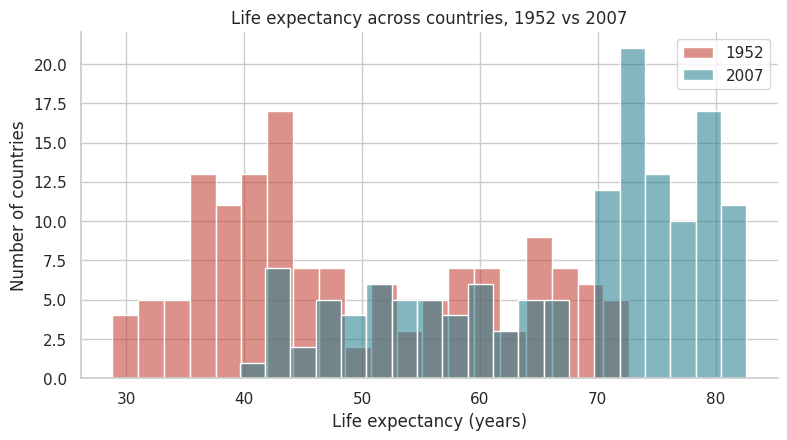

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for yr, col in [(1952, "#c0392b"), (2007, "#1f7a8c")]:
    sns.histplot(gap[gap.year == yr].lifeExp, bins=20, alpha=0.55, color=col, label=str(yr), ax=ax)
ax.set(title="Life expectancy across countries, 1952 vs 2007", xlabel="Life expectancy (years)", ylabel="Number of countries")
ax.legend(); sns.despine(); plt.show()

## 4. Relationship: wealth vs life expectancy
GDP per person spans a huge range, so a **log scale** on the x-axis makes the pattern readable. Small multiples (one panel per continent) avoid overplotting.

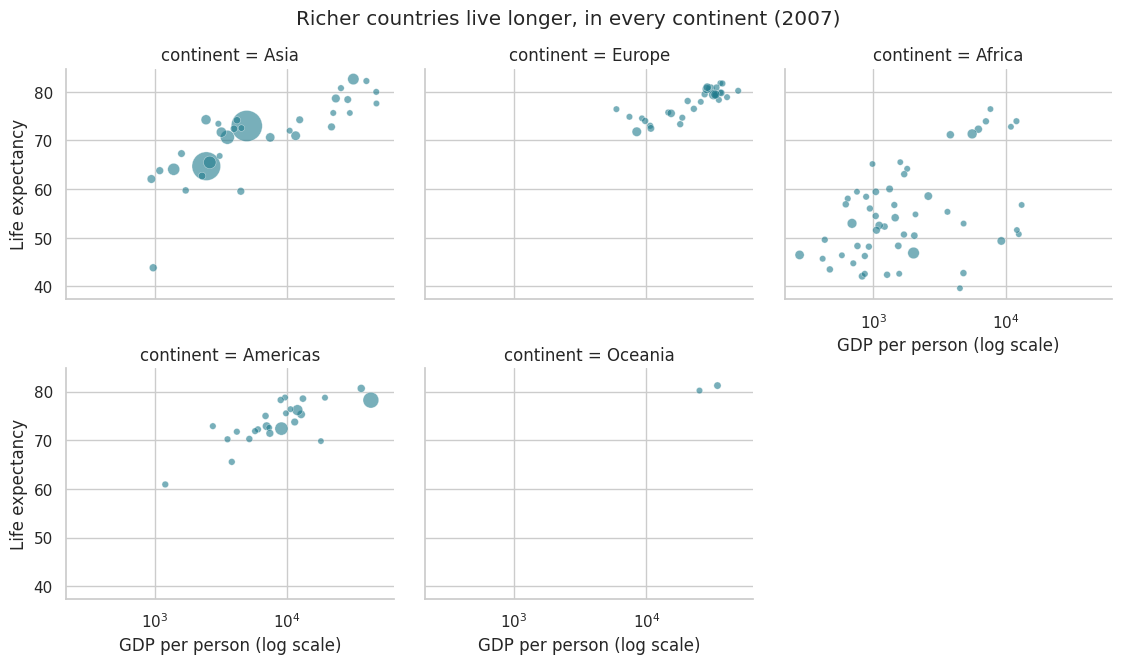

In [4]:
g = sns.relplot(data=gap[gap.year == 2007], x="gdpPercap", y="lifeExp", col="continent", col_wrap=3,
                size="pop", sizes=(20, 500), alpha=0.6, height=3.2, aspect=1.2, legend=False, color="#1f7a8c")
g.set(xscale="log", xlabel="GDP per person (log scale)", ylabel="Life expectancy")
g.figure.suptitle("Richer countries live longer, in every continent (2007)", y=1.03)
plt.show()

## 5. Trend: population-weighted life expectancy by continent
We weight by population so large countries count more, which is a fairer continent average.

In [5]:
gap["lp"] = gap.lifeExp * gap["pop"]
trend = gap.groupby(["continent", "year"]).agg(lp=("lp", "sum"), pop=("pop", "sum")).reset_index()
trend["lifeExp"] = trend.lp / trend["pop"]

fig = px.line(trend, x="year", y="lifeExp", color="continent", markers=True,
              title="Life expectancy by continent (population-weighted)",
              labels={"lifeExp": "Life expectancy (years)", "year": ""})
fig.update_layout(hovermode="x unified", legend_title_text="")
fig.show()

## 6. Heatmap: comparing two categories at once
Using the Tips dataset: which day and time have the most generous tips?

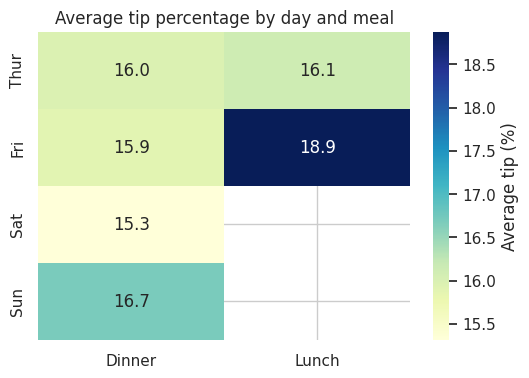

In [6]:
tips["tip_pct"] = tips.tip / tips.total_bill * 100
pivot = tips.pivot_table(index="day", columns="time", values="tip_pct", aggfunc="mean").reindex(["Thur", "Fri", "Sat", "Sun"])
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Average tip (%)"})
plt.title("Average tip percentage by day and meal"); plt.ylabel(""); plt.xlabel(""); plt.show()

## 7. Interactive: the animated bubble chart
Press **Play** or drag the slider to watch countries move from 1952 to 2007. Hover over a bubble for details.

In [7]:
fig = px.scatter(gap, x="gdpPercap", y="lifeExp", animation_frame="year", animation_group="country",
                 size="pop", color="continent", hover_name="country", log_x=True, size_max=55,
                 range_x=[100, 100000], range_y=[25, 90],
                 labels={"gdpPercap": "GDP per person (log scale)", "lifeExp": "Life expectancy"},
                 title="Wealth and health, 1952 to 2007")
fig.show()

## 8. Map: where do people live longest?

In [8]:
fig = px.choropleth(gap[gap.year == 2007], locations="iso_alpha", color="lifeExp", hover_name="country",
                    color_continuous_scale="Viridis", range_color=(40, 83),
                    labels={"lifeExp": "Life expectancy"}, title="Life expectancy by country, 2007")
fig.update_layout(margin=dict(l=0, r=0, t=50, b=0))
fig.show()

## 9. Time series with a range slider
Stock prices (weekly, 2018 to 2019), indexed so every company starts at 100 for a fair comparison.

In [9]:
long = stocks.melt(id_vars="date", var_name="company", value_name="price")
long["indexed"] = long.groupby("company").price.transform(lambda s: s / s.iloc[0] * 100)
fig = px.line(long, x="date", y="indexed", color="company", title="Stock performance (start = 100)",
              labels={"indexed": "Index (start = 100)", "date": ""})
fig.update_xaxes(rangeslider_visible=True)
fig.show()

## 10. Good vs bad chart design
Same data, two charts. Which is easier to read?

In [10]:
pop07 = gap[gap.year == 2007].groupby("continent")["pop"].sum().reset_index().sort_values("pop", ascending=False)
pop07["pop_bn"] = pop07["pop"] / 1e9
fig1 = px.pie(pop07, names="continent", values="pop_bn", title="Hard: comparing pie slices")
fig2 = px.bar(pop07, x="continent", y="pop_bn", text=pop07.pop_bn.round(2), title="Easy: comparing bar lengths",
              labels={"pop_bn": "Population (billions)", "continent": ""})
fig2.update_traces(marker_color="#1f7a8c", textposition="outside")
fig1.show(); fig2.show()

**Design checklist**
- Choose the chart for the question: distribution (histogram), relationship (scatter), trend (line), comparison (bar), place (map).
- Titles should state the *finding*, not just the topic.
- Label axes with units; use a log scale when values span orders of magnitude.
- Use colour with purpose and check it works for colour-blind readers.
- Remove clutter: no 3D effects, fewer gridlines, avoid pies with many slices.
- Start bar charts at zero.

## 11. Save and share
Interactive Plotly charts can be saved as standalone HTML files and hosted on GitHub Pages.

In [11]:
fig = px.scatter(gap[gap.year == 2007], x="gdpPercap", y="lifeExp", size="pop", color="continent",
                 hover_name="country", log_x=True, size_max=55, title="Wealth and health, 2007")
fig.write_html("wealth_and_health_2007.html")
print("Saved wealth_and_health_2007.html (download it from the Colab file panel)")

Saved wealth_and_health_2007.html (download it from the Colab file panel)


## 12. Takeaways
- Write 3 findings in your own words (for example: how much life expectancy rose, which continent improved most, how the wealth gap looks today).
- **Limitations:** country averages hide differences inside countries; the data stops at 2007.

## Next steps
Build a Streamlit or Dash dashboard, use newer World Bank data, or animate the choropleth map by year.

## References
- Gapminder Foundation: https://www.gapminder.org
- Plotly Express documentation: https://plotly.com/python/plotly-express/